In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

### Lifted Lasso Posterior and Langevin Sampling

We consider the Lasso posterior $\pi(x) \propto \exp\Big(-\beta (\tfrac{1}{2} \|Ax - y\|_2^2 + \lambda \|x\|_1) \Big)$

To handle the non-smooth $|x|$ term, we introduce an latent variables $u$ and $v$ such that $x = u \odot v$, where $\odot\$ denotes the element-wise product. 

Using the identity $|x_i| = \min_{u_i v_i = x_i} \frac{1}{2}\left(u_i^2 + v_i^2\right)$, the $\ell_1\$ penalty is replaced by a smooth quadratic function.

$H(u,v) = \frac{1}{2} \| A (u \odot v) - y \|_2^2 + \frac{\lambda}{2} (\|u\|_2^2 + \|v\|_2^2)$

The posterior is now $\pi(u,v) \propto \exp\Big(-\beta H(u,v)\Big)$

$\nabla_u H(u,v) = (A (u \odot v) - y)^\top A \odot v + \lambda u$

$\nabla_v H(u,v) = (A (u \odot v) - y)^\top A \odot u + \lambda v$


#### Euler–Maruyama Discretisation Steps:

$u_{k+1} = u_k - \delta \, \nabla_u H(u_k, v_k) + \sqrt{\frac{2\delta}{\beta}} \, z_k$

$v_{k+1} = v_k - \delta \, \nabla_v H(u_k, v_k) + \sqrt{\frac{2\delta}{\beta}} \, w_k$

where $z_k, w_k \sim \mathcal{N}(0, I_d)$ are independent Gaussian noise vectors, and $\delta > 0$ is the step size.

Finally, the samples of the original variable are reconstructed as $x_k = u_k \odot v_k$

In [27]:
def hadamard_langevin(Beta, Lambda, step, n_samples, burn_in):

    np.random.seed(0)

    y = 1.0
    u = 1.0
    v = 1.0

    samples = []

    for k in range(n_samples):

        residual = u * v - y

        grad_u = residual * v + Lambda * u
        grad_v = residual * u + Lambda * v

        noise_u = np.sqrt(2 * step / Beta) * np.random.randn()
        noise_v = np.sqrt(2 * step / Beta) * np.random.randn()

        u = u - step * grad_u + noise_u
        v = v - step * grad_v + noise_v

        if k >= burn_in:
            samples.append(u * v)

    return np.array(samples)

In [28]:
def exact_posterior(x):
    x = np.asarray(x)

    Z = (np.sqrt(np.pi) / 2) * (np.exp(-1) + np.exp(3) * (1 - erf(2)))

    pdf = np.zeros_like(x, dtype=float)

    pos = x >= 0
    neg = x < 0

    pdf[pos] = np.exp(-1) * np.exp(-x[pos]**2)
    pdf[neg] = np.exp(3) * np.exp(-(x[neg] - 2)**2)

    return pdf / Z

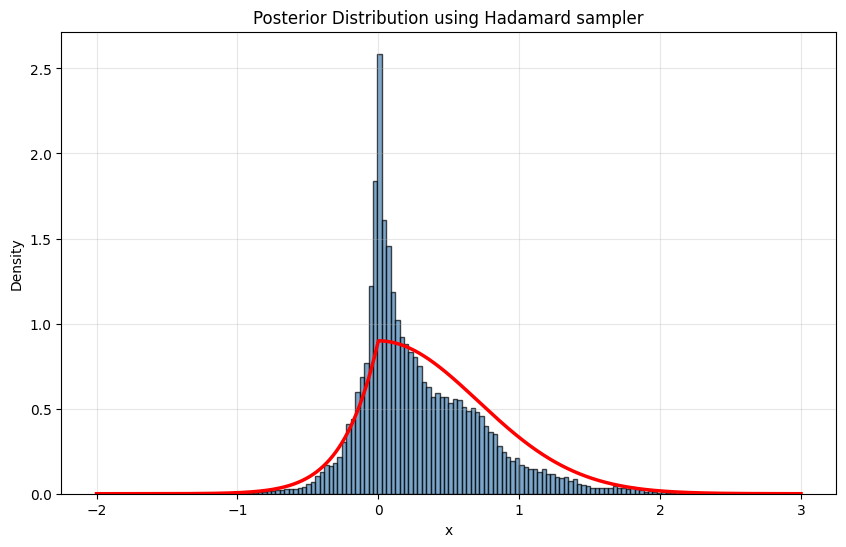

In [29]:
samples_hadamard = hadamard_langevin(Beta=2, Lambda=1, step=0.001, n_samples=50000, burn_in=5000)

x_plot = np.linspace(-2, 3, 10000)
y_exact = exact_posterior(x_plot)

plt.figure(figsize=(10, 6))
plt.hist(samples_hadamard.flatten(), bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='black')
plt.plot(x_plot, y_exact, 'r-', linewidth=2.5, label='Exact Posterior')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Posterior Distribution using Hadamard sampler')
plt.grid(True, alpha=0.3)
plt.show()